# 3.0 — Análisis Exploratorio del Dataset RFM
**Autor:** Ian Gallego | Politécnico Malvinas Argentinas | 2026

---
Analiza la tabla de clientes (`clientes_rfm.parquet`) antes del clustering:
correlaciones entre features, detección de outliers, segmentación cualitativa por
localidad/canal y exploración heurística de B2B vs B2C. Este notebook **justifica
visualmente** por qué `ticket_promedio` y otras complementarias **no** entran al clustering.

## 1. Carga

In [1]:
# Setup: agregar el root del proyecto al sys.path para importar segmentacion/
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from segmentacion.plots import heatmap_correlacion
from segmentacion.features import FEATURES_CLUSTERING, FEATURES_CARACTERIZACION
from segmentacion.config import PROCESSED_DATA_DIR, INTERIM_DATA_DIR, FIGURES_DIR

clientes = pd.read_parquet(PROCESSED_DATA_DIR / 'clientes_rfm.parquet')
transacciones = pd.read_parquet(INTERIM_DATA_DIR / 'transacciones_limpias.parquet')
print(f'Clientes: {len(clientes):,}  |  Transacciones: {len(transacciones):,}')
print(f'FEATURES_CLUSTERING = {FEATURES_CLUSTERING}')
print(f'FEATURES_CARACTERIZACION = {FEATURES_CARACTERIZACION}')

2026-06-03 20:02:20.413 | INFO     | segmentacion.config:<module>:11 - PROJ_ROOT path is: F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut


Clientes: 4,992  |  Transacciones: 49,909
FEATURES_CLUSTERING = ['recency', 'frequency', 'monetary_log']
FEATURES_CARACTERIZACION = ['recency', 'frequency', 'monetary', 'ticket_promedio', 'diversidad_categorias', 'antiguedad']


## 2. Heatmap de correlación — justificación del set de clustering
Mostramos correlaciones entre **todas** las features (RFM + complementarias).
Si alguna complementaria está fuertemente correlacionada con las RFM (especialmente
`ticket_promedio` con `monetary` y `frequency`, ya que es su cociente), debe quedar
**fuera del clustering** para evitar sobreponderar la dimensión gasto.

2026-06-03 20:02:21.254 | INFO     | segmentacion.plots:_save:19 - Figura guardada: F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut\reports\figures\nb3_heatmap.png


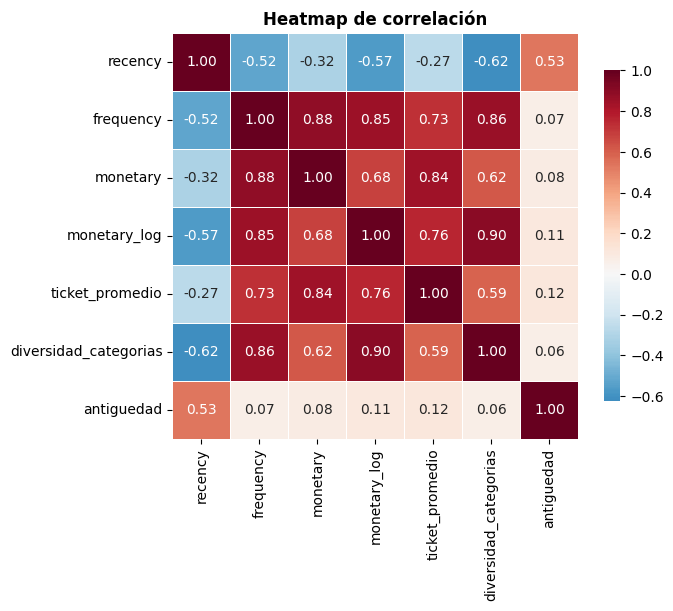

In [2]:
cols_corr = ['recency', 'frequency', 'monetary', 'monetary_log',
             'ticket_promedio', 'diversidad_categorias', 'antiguedad']
heatmap_correlacion(clientes, cols_corr, output=FIGURES_DIR / 'nb3_heatmap.png')
plt.show()

### 🔍 Lectura del heatmap

Dos observaciones importantes:

1. **`ticket_promedio` está fuertemente correlacionado con `monetary` y `frequency`**
   (correlaciones > 0.6). Esto es **por construcción**: `ticket_promedio = monetary / frequency`.
   Incluirla en el clustering haría que la dimensión "gasto" pese el triple. **Por eso queda
   FUERA del clustering** y se usa solo para caracterizar los segmentos a posteriori.

2. **`frequency` ↔ `monetary_log` ≈ 0.85** es alta pero esperable en RFM: los clientes que
   compran más veces también gastan más. Esto significa que el clustering aprovecha
   información parcialmente redundante entre F y M, pero es una limitación aceptada porque
   los 3 ejes RFM (R, F, M) son el estándar de la literatura — eliminar uno reduciría la
   interpretabilidad. **El log1p sobre M ayuda a desacoplarlas parcialmente.**

**Lectura del heatmap:** la correlación esperada entre `ticket_promedio` y
`monetary` / `frequency` confirma la multicolinealidad que motivó dejar las
complementarias **fuera** del set de clustering. Para el modelo solo usaremos
`recency`, `frequency` y `monetary_log` (RFM puro).

## 3. Detección de outliers

In [3]:
def detectar_outliers_iqr(s: pd.Series) -> pd.Series:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)

resumen = {}
for col in ['recency', 'frequency', 'monetary', 'ticket_promedio']:
    out = detectar_outliers_iqr(clientes[col])
    resumen[col] = {'n_outliers': int(out.sum()), 'pct': round(out.mean()*100, 2)}

pd.DataFrame(resumen).T

,n_outliers,pct
recency,0.0,0.00
frequency,184.0,3.69
monetary,765.0,15.32
ticket_promedio,669.0,13.40


## 4. Análisis cualitativo — localidad, canal, categoría

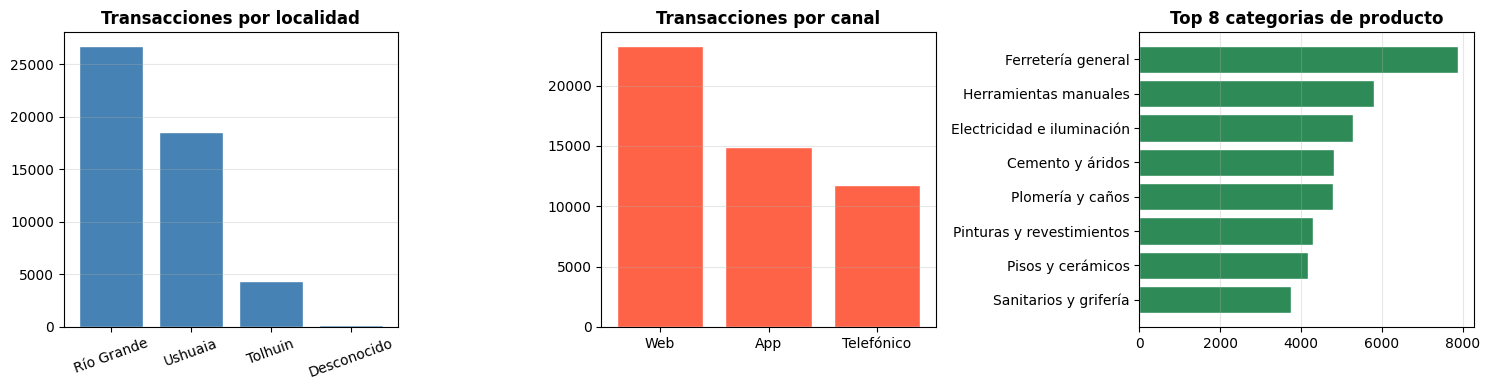

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

trans_loc = transacciones['localidad'].value_counts()
axes[0].bar(trans_loc.index, trans_loc.values, color='steelblue', edgecolor='white')
axes[0].set_title('Transacciones por localidad', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)

trans_canal = transacciones['canal_venta'].value_counts()
axes[1].bar(trans_canal.index, trans_canal.values, color='tomato', edgecolor='white')
axes[1].set_title('Transacciones por canal', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

trans_cat = transacciones['categoria_producto'].value_counts().head(8)
axes[2].barh(trans_cat.index[::-1], trans_cat.values[::-1], color='seagreen', edgecolor='white')
axes[2].set_title('Top 8 categorias de producto', fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb3_contexto_categorico.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Exploración heurística: B2B vs B2C
Hipótesis del README: clientes B2B = `frequency` alta + `monetary` alta + `diversidad`
amplia. Identificamos como **probables B2B** a quienes están en el cuartil superior
tanto de `frequency` como de `monetary`.

In [5]:
q3_freq = clientes['frequency'].quantile(0.75)
q3_mon  = clientes['monetary'].quantile(0.75)
clientes['probable_b2b'] = ((clientes['frequency'] >= q3_freq) & (clientes['monetary'] >= q3_mon))

n_b2b = int(clientes['probable_b2b'].sum())
print(f'Probables B2B (Q3 frequency y Q3 monetary): {n_b2b:,} clientes ({n_b2b/len(clientes)*100:.1f} %)')
print('\nPerfil B2B vs B2C (medias):')
clientes.groupby('probable_b2b')[['recency','frequency','monetary','ticket_promedio','diversidad_categorias','antiguedad']].mean().round(1)

Probables B2B (Q3 frequency y Q3 monetary): 1,062 clientes (21.3 %)

Perfil B2B vs B2C (medias):


,recency,frequency,monetary,ticket_promedio,diversidad_categorias,antiguedad
probable_b2b,,,,,,
False,272.9,6.0,387899.9,62346.0,4.2,470.8
True,76.1,24.9,6156192.5,213741.4,9.7,497.8


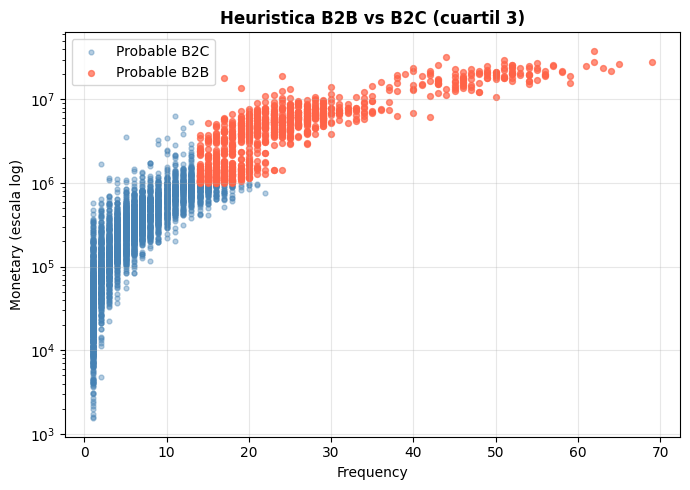

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(clientes.loc[~clientes['probable_b2b'], 'frequency'],
           clientes.loc[~clientes['probable_b2b'], 'monetary'],
           c='steelblue', s=12, alpha=0.4, label='Probable B2C')
ax.scatter(clientes.loc[clientes['probable_b2b'], 'frequency'],
           clientes.loc[clientes['probable_b2b'], 'monetary'],
           c='tomato', s=18, alpha=0.7, label='Probable B2B')
ax.set_yscale('log')
ax.set_xlabel('Frequency')
ax.set_ylabel('Monetary (escala log)')
ax.set_title('Heuristica B2B vs B2C (cuartil 3)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb3_b2b_vs_b2c.png', dpi=120, bbox_inches='tight')
plt.show()

**Conclusión del EDA RFM:**
1. `ticket_promedio` está fuertemente correlacionado con `monetary` (por construcción) → fuera del clustering.
2. La distribución muestra un gradiente continuo entre B2C masivo y B2B premium.
3. Las complementarias (`diversidad_categorias`, `antiguedad`) se reservan para **caracterizar** segmentos a posteriori, no para entrenar.

## 📋 TL;DR del notebook 3
- **Entrada:** `data/processed/clientes_rfm.parquet`
- **Salida:** sin persistencia — análisis exploratorio que guía las decisiones del NB4
- **Hallazgo clave:** `ticket_promedio` está fuertemente correlacionado con `monetary` (≈ 0.85) → **fuera del clustering**
- **Heurística B2B/B2C:** clientes en cuartil superior de F y M se marcan como probables B2B
- **Siguiente paso:** notebook 4 → aplicar y comparar K-Means, DBSCAN, Jerárquico